# ISH-LITE and UFS-CHEM

Our first example will demonstrate the basics available in MELODIES MONET to 
compare UFS-CHEM results against ISH-LITE surface observations for temperature, wind speed, and dewpoint.

ISH is a particularly useful for model evaluations because it is a global dataset. As you will see in the YAML file, we can create plots globally, for individual countries, and states. NOTE: MELODIES-MONET examples that use ISH will take longer to finish running due to the larger amount of data.

First, we import the {mod}`melodies_monet.driver` module.

In [1]:
from melodies_monet import driver

## Analysis driver class

Now, lets create an instance of the analysis driver class, {class}`melodies_monet.driver.analysis`.
It consists of these main parts:
* model instances
* observation instances
* a paired instance of both

In [2]:
an = driver.analysis()

Initially, most of our {class}`~melodies_monet.driver.analysis` object's attributes
are set to ``None``, though some have meaningful defaults:

In [3]:
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control file

We set the YAML control file and begin by reading the file.

```{note}
Check out the {doc}`/appendix/yaml` for info on how to create
and modify these files.
```

In [4]:
an.control = "control_ish_lite_ufschem-example.yaml"
an.read_control()
an.control_dict

{'analysis': {'start_time': '2017-07-01-00:00:00',
  'end_time': '2017-07-03-00:00:00',
  'output_dir': './output/ish_lite_ufschem',
  'debug': True},
 'model': {'ufschem_v1': {'files': 'example:ufschem:2017-07',
   'mod_type': 'ufschem',
   'mod_kwargs': {'surf_only': True},
   'radius_of_influence': 100000,
   'extra_calc': {'dewpoint': {'specific_hum': 'spfh'},
    'rel_hum': {'specific_hum': 'spfh'},
    'windspeed': {'u_comp': 'ugrd', 'v_comp': 'vgrd'},
    'winddir': {'u_comp': 'ugrd', 'v_comp': 'vgrd'},
    'wind_barb': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}},
   'mapping': {'ish_lite': {'temperature_k': 'temp',
     'windspeed': 'ws',
     'dewpoint': 'dew_pt_temp'}},
   'variables': {'winddir': 'wdir'},
   'projection': None,
   'plot_kwargs': {'color': 'magenta', 'marker': 's', 'linestyle': '-'}}},
 'obs': {'ish_lite': {'use_ish_lite': True,
   'filename': 'example:ish-lite:2017-07',
   'obs_type': 'pt_sfc',
   'variables': {'temp': {'unit_scale': 273.15,
     'unit_scale_metho

````{admonition} Note: This is the complete file that was loaded.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
```
````

Now, some of our {class}`~melodies_monet.driver.analysis` object's attributes are populated:

In [5]:
an

analysis(
    control='control_ish_lite_ufschem-example.yaml',
    control_dict=...,
    models={},
    obs={},
    paired={},
    start_time=Timestamp('2017-07-01 00:00:00'),
    end_time=Timestamp('2017-07-03 00:00:00'),
    time_intervals=None,
    download_maps=True,
    output_dir='./output/ish_lite_ufschem',
    output_dir_save='./output/ish_lite_ufschem',
    output_dir_read='./output/ish_lite_ufschem',
    debug=True,
    save=None,
    read=None,
    regrid=False,
)

## Load the model data

The driver will automatically loop through the "models" found in the `model` section
of the YAML file and create an instance of {class}`melodies_monet.driver.model` for each
that includes the
* label
* mapping information
* file names (can be expressed using a glob expression)
* xarray object

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 24-56
```
````

In [6]:
an.open_models()

ufschem
example:ufschem:2017-07
**** Reading UFS-CHEM model output...
Performing extra calculations...
Calculating Dewpoint...
Calculating relative humidity...
Calculating windpseed...
Calculating wind direction...
Calculating wind barbs...


Applying {meth}`~melodies_monet.driver.analysis.open_models`
populates the {attr}`~melodies_monet.driver.analysis.models` attribute.

In [7]:
an.models

{'ufschem_v1': model(
     model='ufschem',
     is_global=False,
     radius_of_influence=100000,
     mod_kwargs={'surf_only': True, 'var_list': ['spfh', 'ugrd', 'vgrd', 'lat', 'lon', 'phalf', 'tmp', 'pressfc', 'dpres', 'hgtsfc', 'delz']},
     file_str='example:ufschem:2017-07',
     label='ufschem_v1',
     obj=...,
     extra_calc={'dewpoint': {'specific_hum': 'spfh'}, 'rel_hum': {'specific_hum': 'spfh'}, 'windspeed': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}, 'winddir': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}, 'wind_barb': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}},
     mapping={'ish_lite': {'temperature_k': 'temp', 'windspeed': 'ws', 'dewpoint': 'dew_pt_temp'}},
     variable_dict={'winddir': 'wdir', 'spfh': 'None', 'ugrd': 'None', 'vgrd': 'None'},
     label='ufschem_v1',
     ...
 )}

We can access the underlying dataset with the
{attr}`~melodies_monet.driver.model.obj` attribute.

In [8]:
an.models['ufschem_v1'].obj

<xarray.Dataset> Size: 341MB
Dimensions:        (time: 72, z: 1, y: 192, x: 384)
Coordinates:
    latitude       (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    longitude      (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
  * time           (time) datetime64[ns] 576B 2017-07-01T01:00:00 ... 2017-07-04
Dimensions without coordinates: z, y, x
Data variables: (12/13)
    spfh           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ugrd           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    vgrd           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    temperature_k  (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    surfpres_pa    (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    dp_pa          (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ...             ...
    dz_m           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    pres_pa_mid    (time, z, y, x) float32 21MB 37.92 37.92 ... 37.92 37.92
    dewpoint       (time, z, y, x) float64 42MB 271.7 271.7 ... 217.3 217.2
    rel_hum        (time, z, y, x) float64 42MB 94.35 94.35 ... 66.12 66.08
    windspeed      (time, z, y, x) float64 42MB 6.511 6.511 6.511 ... 6.09 6.085
    winddir        (time, z, y, x) float32 21MB 203.4 202.6 ... 99.82 100.6
Attributes:
    ak:           [2.0000000e+01 6.4247000e+01 1.3779000e+02 2.2195800e+02 3....
    bk:           [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0....
    grid:         gaussian
    grid_id:      1
    hydrostatic:  non-hydrostatic
    im:           384
    jm:           192
    ncnsto:       139
    source:       FV3GFS
    history:      Wed Jun 25 09:54:47 2025: ncrcat 20170701_dynf001.nc 201707...
    NCO:          netCDF Operators version 5.0.7 (Homepage = http://nco.sf.ne...

## Load the observational data

As with the model data, the driver will loop through the "observations" found in
the `obs` section of the YAML file and create an instance of
{class}`melodies_monet.driver.observation` for each.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 58-99
```
````

In [9]:
an.open_obs()

In [10]:
an.obs

{'ish_lite': observation(
     obs='ish_lite',
     label='ish_lite',
     file='example:ish-lite:2017-07',
     obj=...,
     type='pt_src',
     sat_type=None,
     data_proc=None,
     variable_dict={'temp': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Temperature (K)', 'xlabel_plot': 'Temperature (K)', 'vmin_plot': 273.15, 'vmax_plot': 313, 'vdiff_plot': 20.0, 'nlevels_plot': 21}, 'ws': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Windspeed (m/s)', 'xlabel_plot': 'Windspeed (m/s)', 'vmin_plot': 0, 'vmax_plot': 15, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'wdir': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Wind Direction (deg)', 'xlabel_plot': 'Wind Direction (deg)', 'vmin_plot': 0, 'vmax_plot': 370, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'dew_pt_temp': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Dewpoint (K)', 'xlabel_plot': 'Dewpoint (K)',

In [11]:
an.obs['ish_lite']

observation(
    obs='ish_lite',
    label='ish_lite',
    file='example:ish-lite:2017-07',
    obj=...,
    type='pt_src',
    sat_type=None,
    data_proc=None,
    variable_dict={'temp': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Temperature (K)', 'xlabel_plot': 'Temperature (K)', 'vmin_plot': 273.15, 'vmax_plot': 313, 'vdiff_plot': 20.0, 'nlevels_plot': 21}, 'ws': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Windspeed (m/s)', 'xlabel_plot': 'Windspeed (m/s)', 'vmin_plot': 0, 'vmax_plot': 15, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'wdir': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Wind Direction (deg)', 'xlabel_plot': 'Wind Direction (deg)', 'vmin_plot': 0, 'vmax_plot': 370, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'dew_pt_temp': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Dewpoint (K)', 'xlabel_plot': 'Dewpoint (K)', 'vmin_plot': 273.15,

## Pair model and observational data

Now, we create a {class}`melodies_monet.driver.pair` for each model--obs pair
using the {meth}`~melodies_monet.driver.analysis.pair_data` routine.

In [12]:
%%time

an.pair_data()

1, in pair data
After pairing:               time    temp  dew_pt_temp   press   wdir   ws  sky_condition  \
0      2017-07-01     NaN          NaN     NaN    NaN  NaN            9.0   
1      2017-07-01     NaN          NaN     NaN    NaN  NaN            NaN   
2      2017-07-01  271.95       271.75  1019.5  320.0  4.0            NaN   
3      2017-07-01  275.15       272.95  1018.2   80.0  2.0            2.0   
4      2017-07-01  274.25       271.05  1019.6  330.0  2.0            NaN   
...           ...     ...          ...     ...    ...  ...            ...   
598334 2017-07-03  298.15       290.05     NaN  360.0  3.6            NaN   
598335 2017-07-03  295.85       284.55     NaN    0.0  0.0            NaN   
598336 2017-07-03  293.35       287.75     NaN  280.0  3.1            NaN   
598337 2017-07-03  301.55       295.45     NaN  340.0  1.5            NaN   
598338 2017-07-03  301.15       296.15     NaN   90.0  1.5            NaN   

        precip_1hr  precip_6hr       siteid

CPU times: user 37.6 s, sys: 14.8 s, total: 52.5 s
Wall time: 58.7 s


In [13]:
an.paired

{'ish_lite_ufschem_v1': pair(
     type='pt_sfc',
     radius_of_influence=1000000.0,
     obs='ish_lite',
     model='ufschem_v1',
     model_vars=['temperature_k', 'windspeed', 'dewpoint'],
     obs_vars=['temp', 'ws', 'dew_pt_temp'],
     filename='ish_lite_ufschem_v1.nc',
 )}

In [14]:
an.paired['ish_lite_ufschem_v1']

pair(
    type='pt_sfc',
    radius_of_influence=1000000.0,
    obs='ish_lite',
    model='ufschem_v1',
    model_vars=['temperature_k', 'windspeed', 'dewpoint'],
    obs_vars=['temp', 'ws', 'dew_pt_temp'],
    filename='ish_lite_ufschem_v1.nc',
)

## MELODIES-MONET now contains several meteorological capabilities 

In addition to previous capabilites and plots, users can now:

* Specify wind barbs
    * Note: users may experience longer wait times if they wish to plot wind barbs
* Create rose plots for pollution and wind speed
    * Rose plots can be aggregated at the CONUS-, EPA region-, and MSA-scale 
* Create boxplots on given intervals for any of the supported meteorological variables 
* Mark statistical significance on boxplots


## Plot

The {meth}`~melodies_monet.driver.analysis.plotting` routine produces plots.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 101-240
```
````

Reference std: 8.197992083365513
Reference std: 2.5053146547193874
Reference std: 7.344387247387126
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Value of fill after reading from scatter_density_config: False
Saving scatter density plot to ./output/ish_lite_ufschem/plot_grp6.scatter_density.temp.2017-07-01_00.2017-07-03_00.all.New York City_ish_lite_vs_ufschem_v1.png...
Processing scatter density plot for model 'ufschem_v1' and observation 'ish_lite'...
Generating scatter plot...
Saving scatter density plot to ./output/ish_lite_ufschem/plot_grp6.scatter_density.temp.2017-07-01_00.2017-07-03_00.all.New York City_ish_lite_vs_ufschem_v1.png...


/home/lthompson/mm/update_boxplots/MELODIES-MONET/melodies_monet/plots/surfplots.py:635: RankWarning: Polyfit may be poorly conditioned
  coeffs=np.polyfit(x_data, y_data, 1)


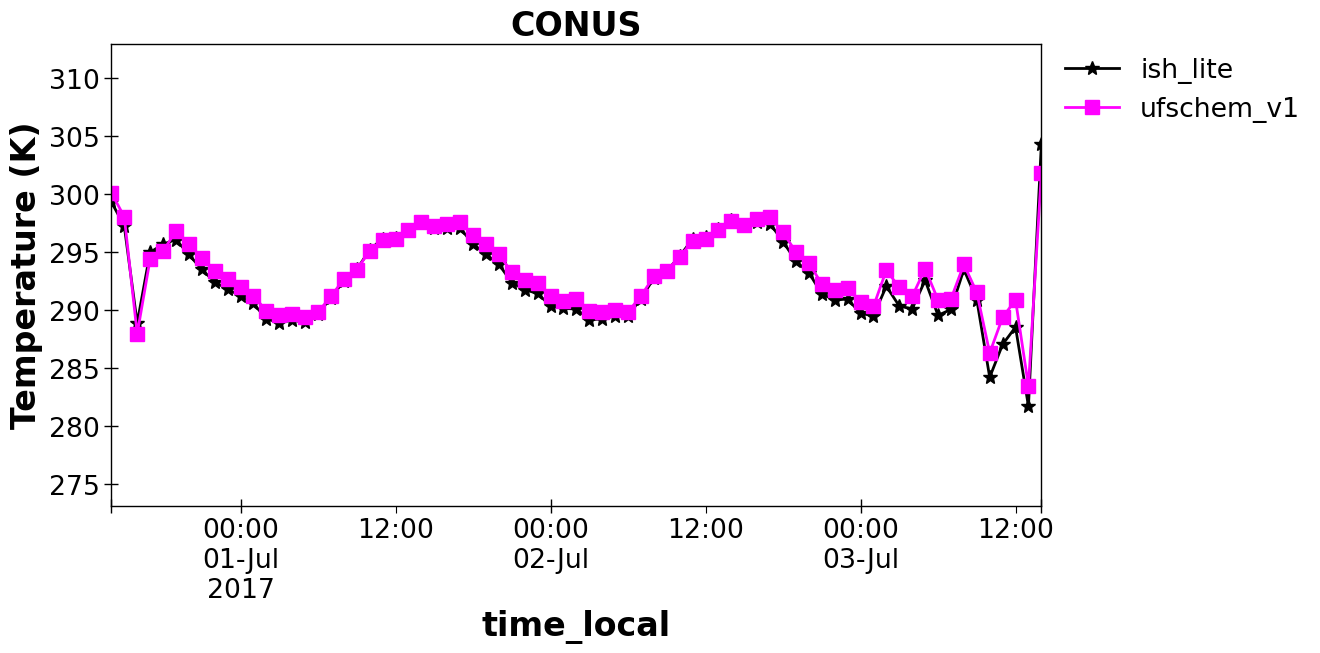

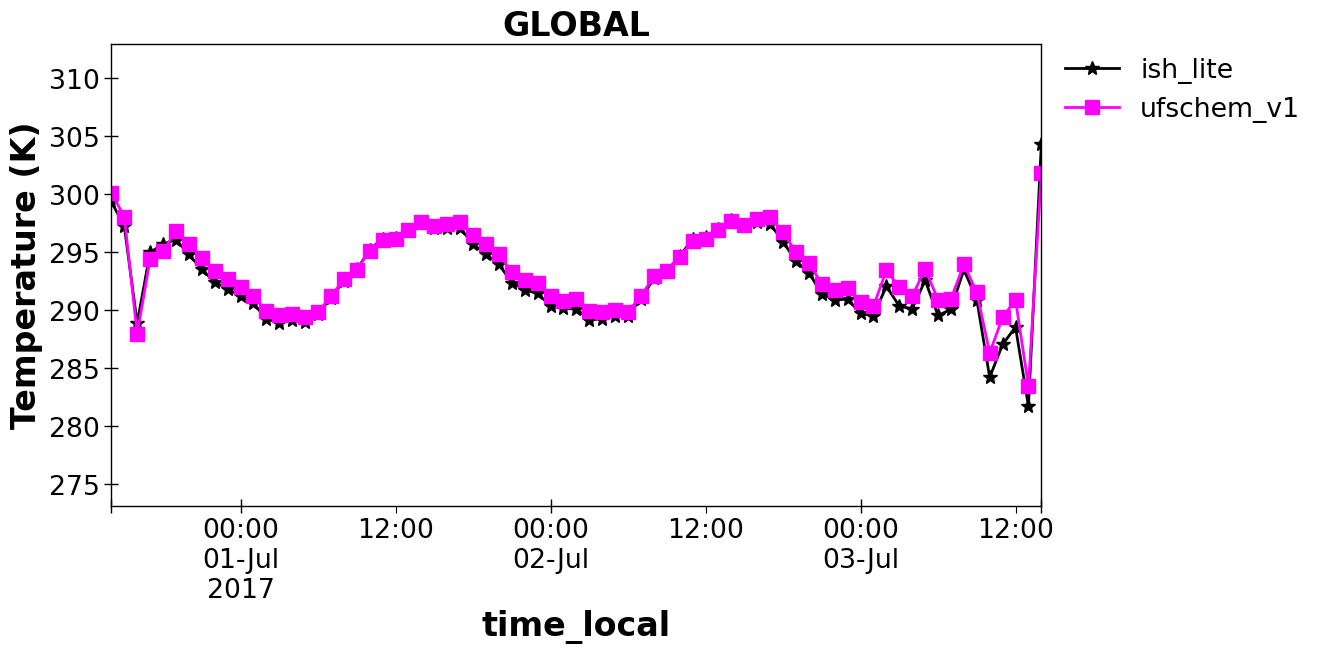

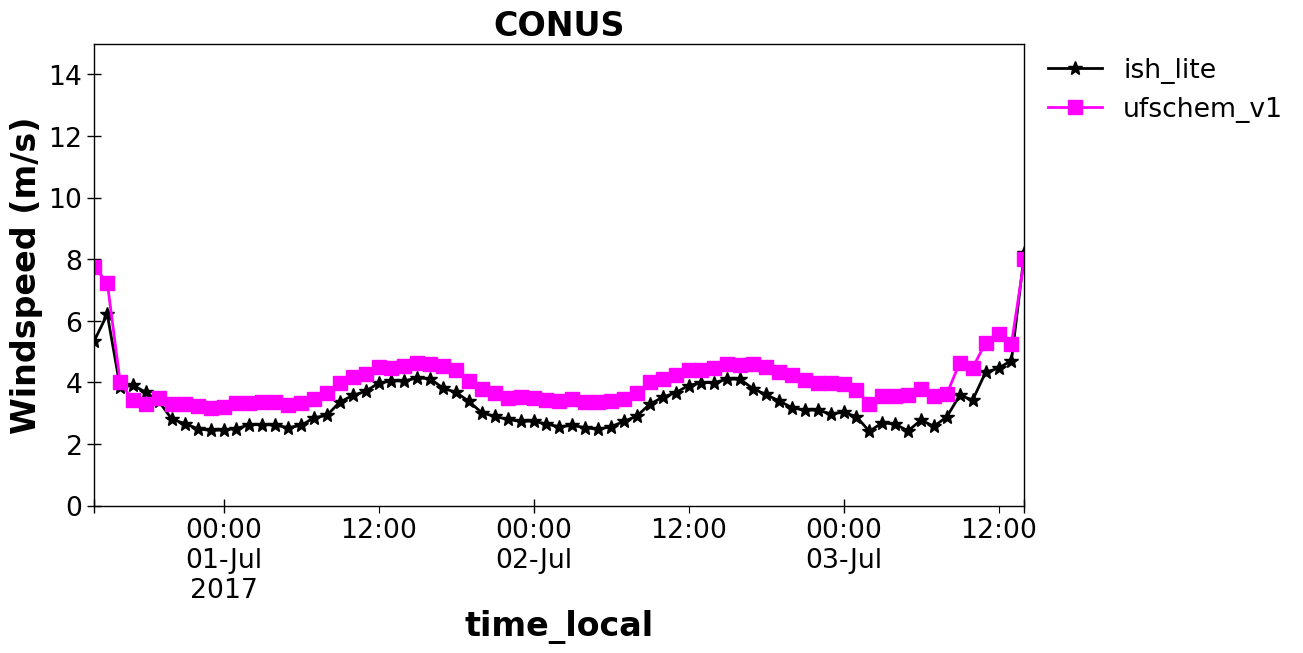

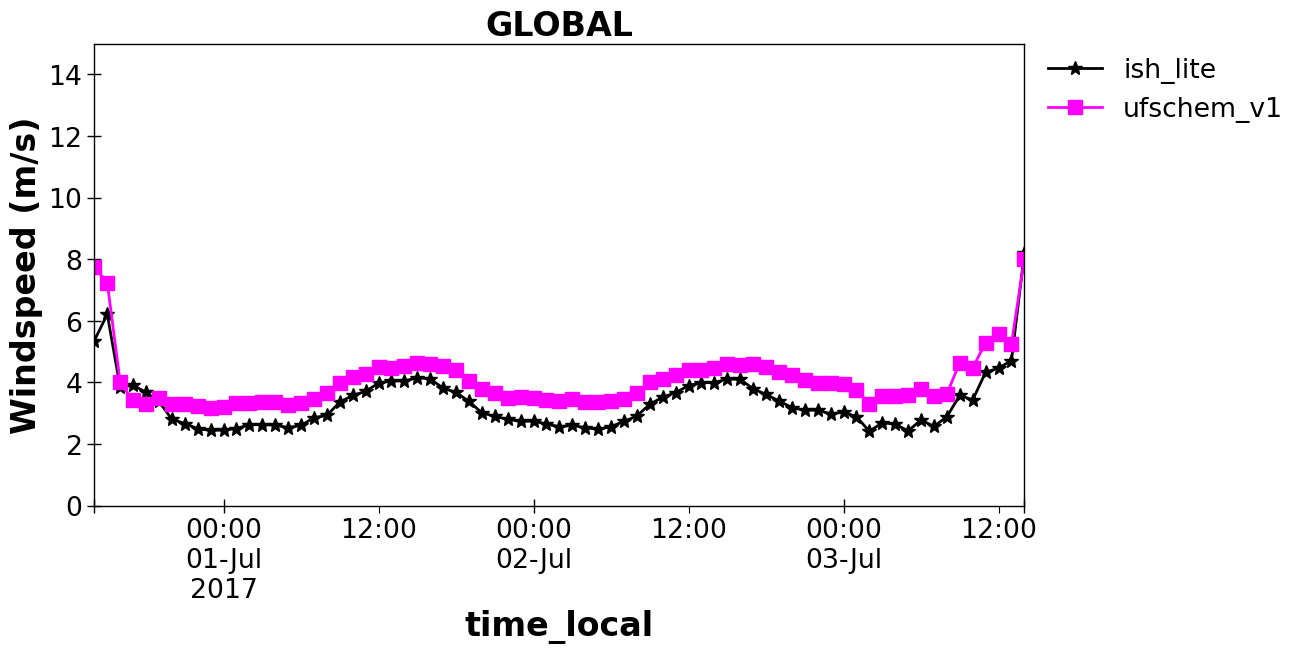

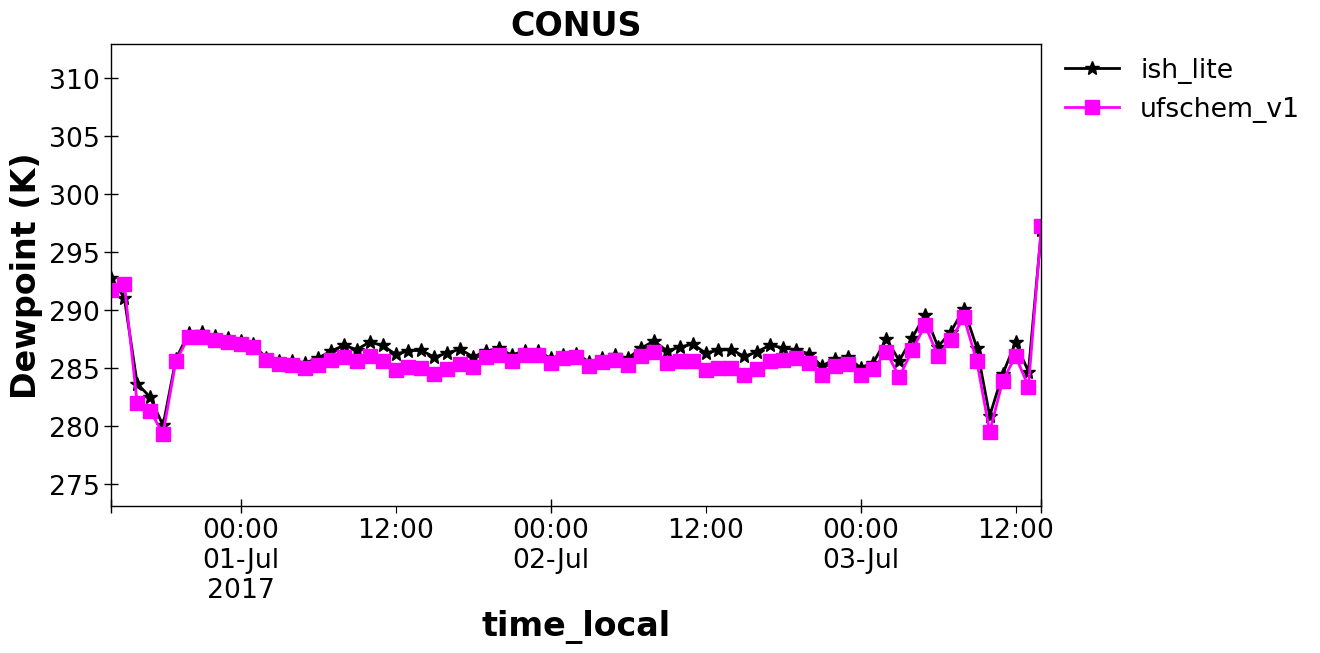

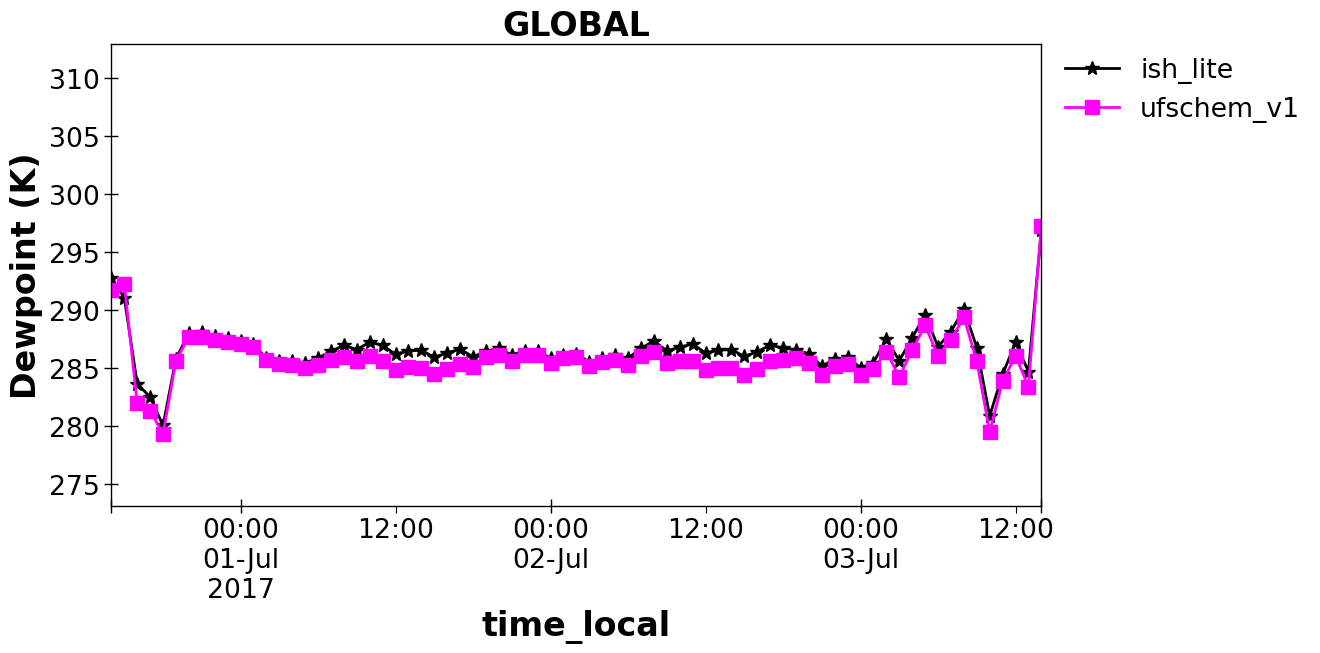

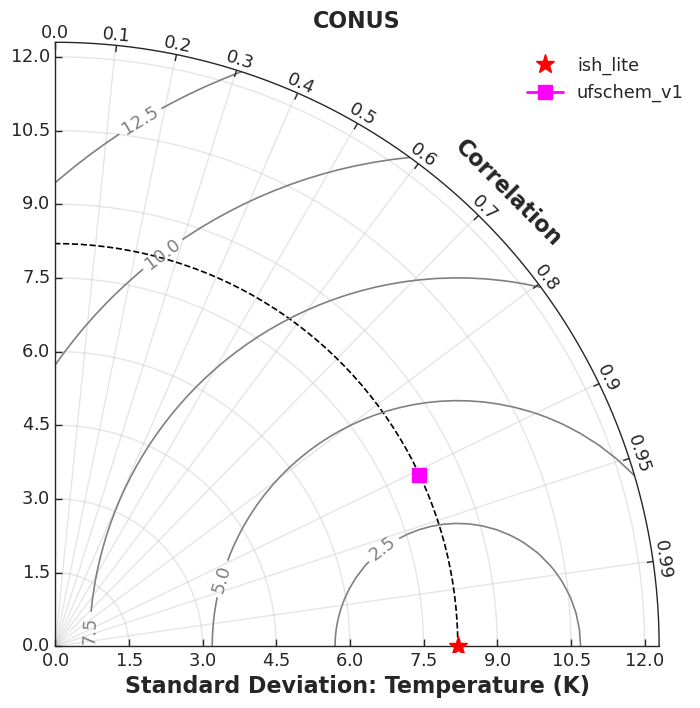

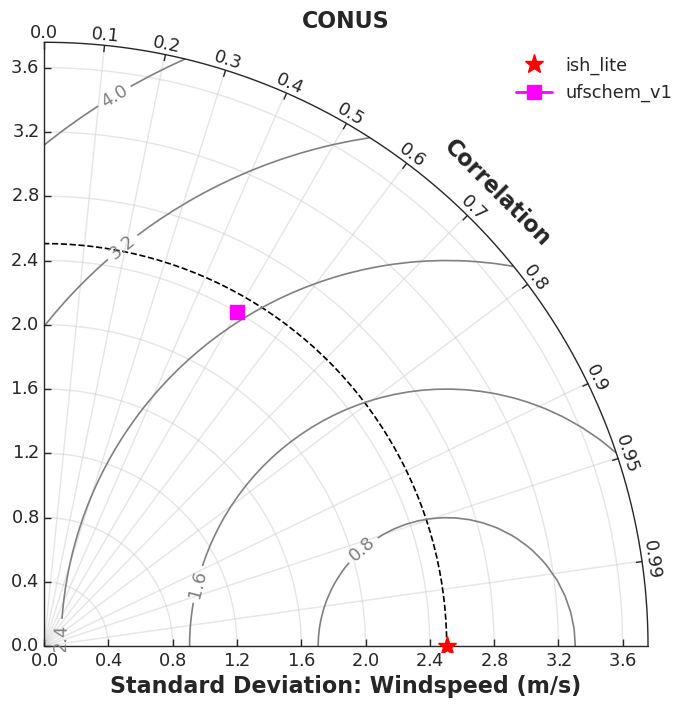

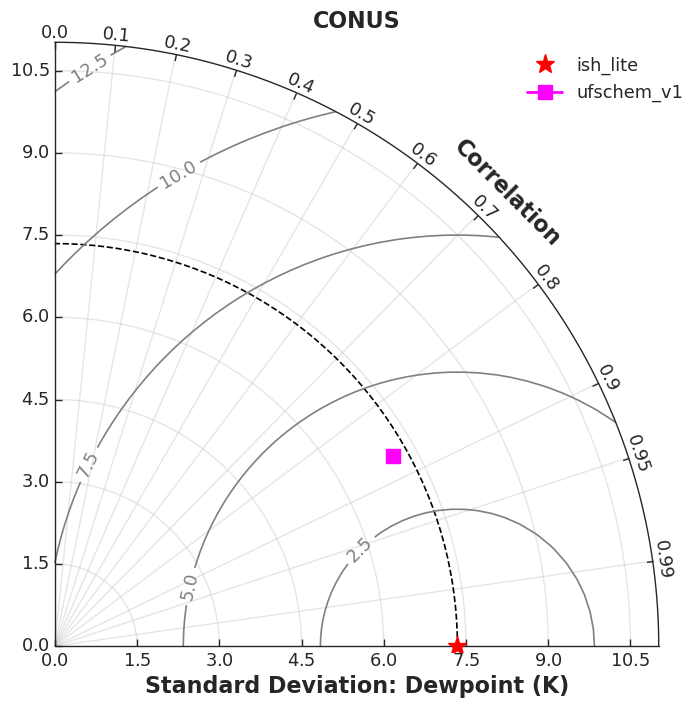

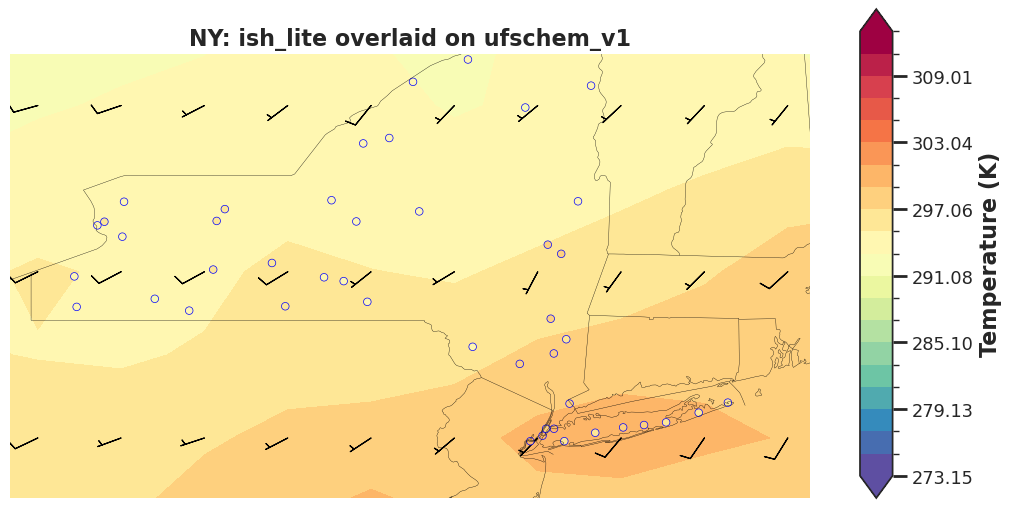

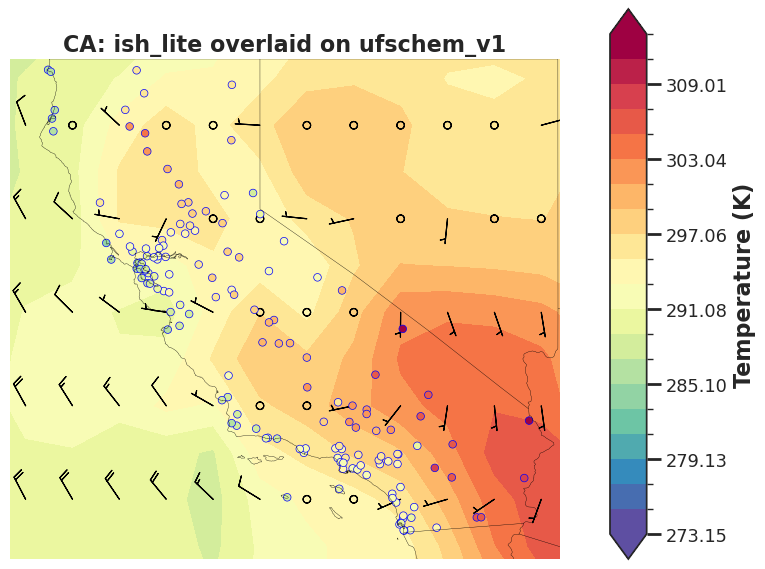

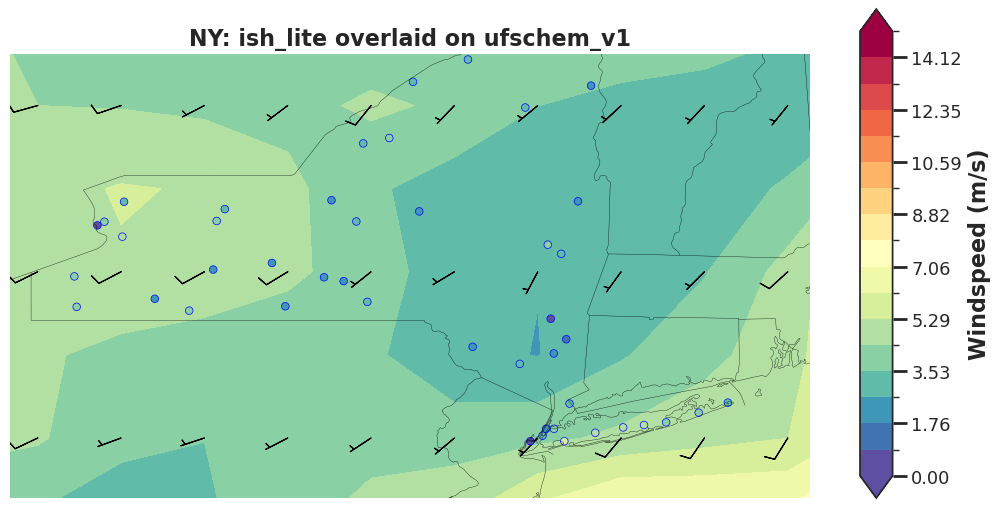

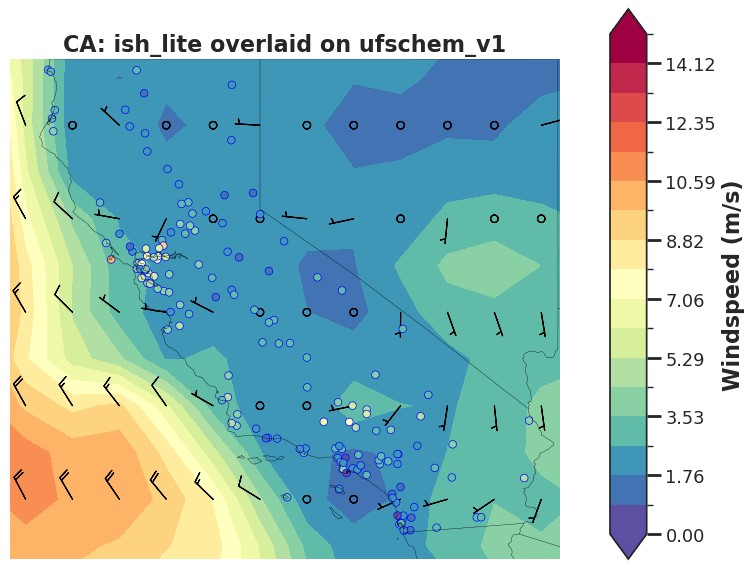

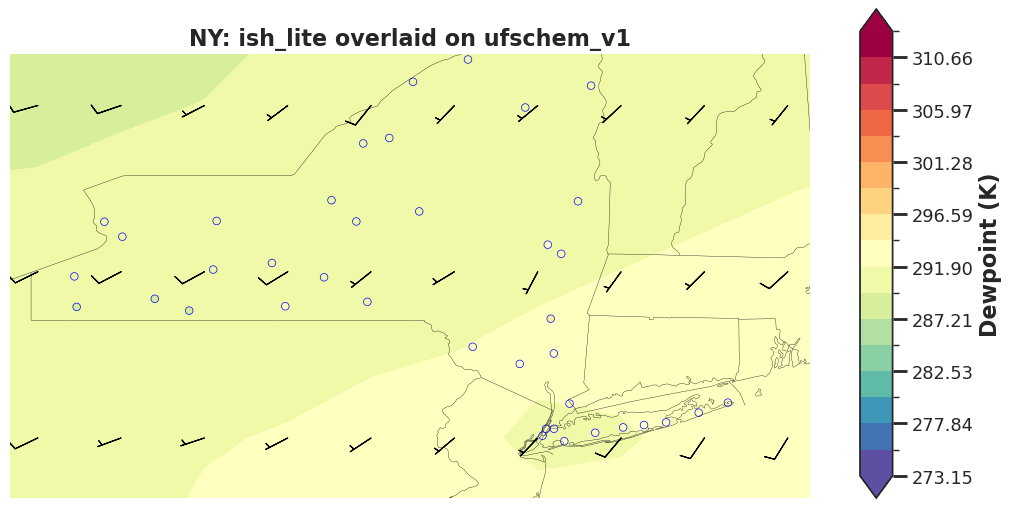

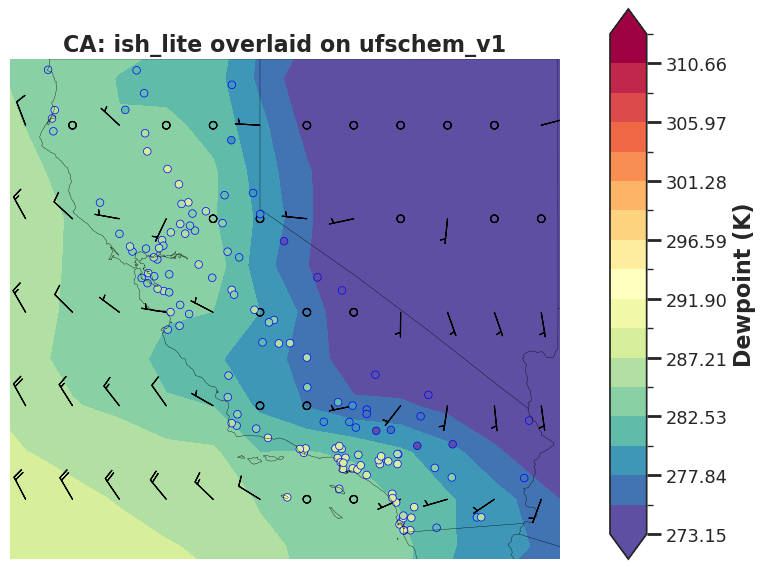

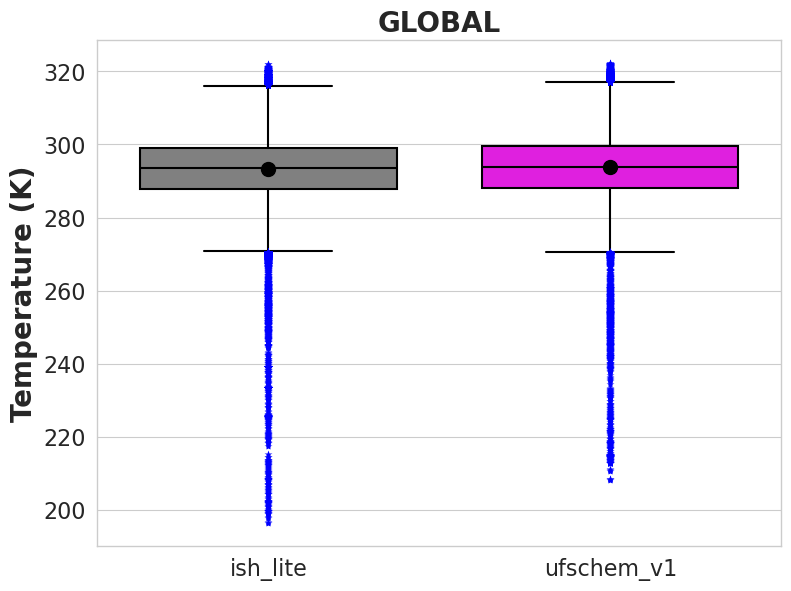

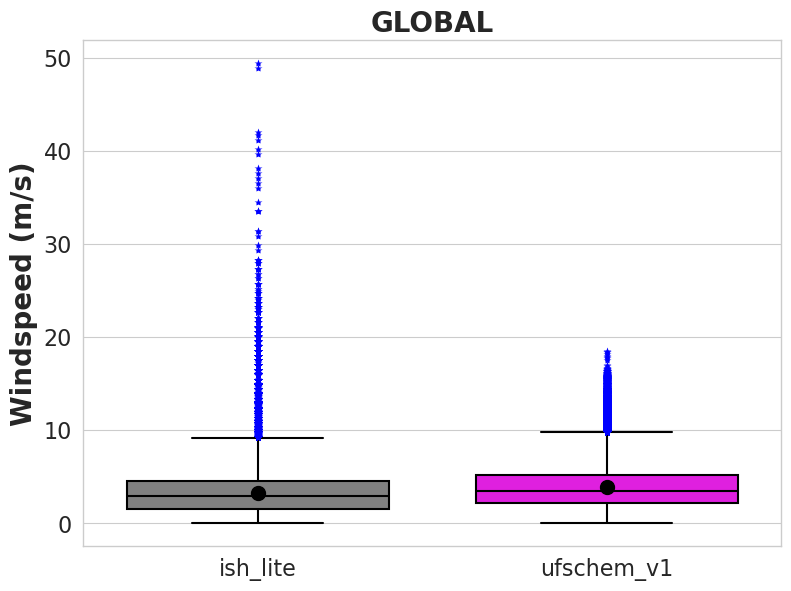

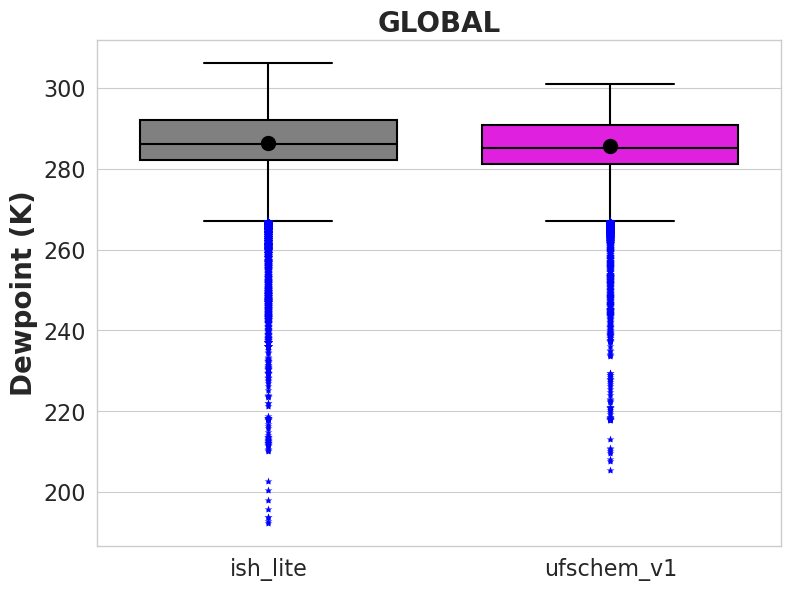

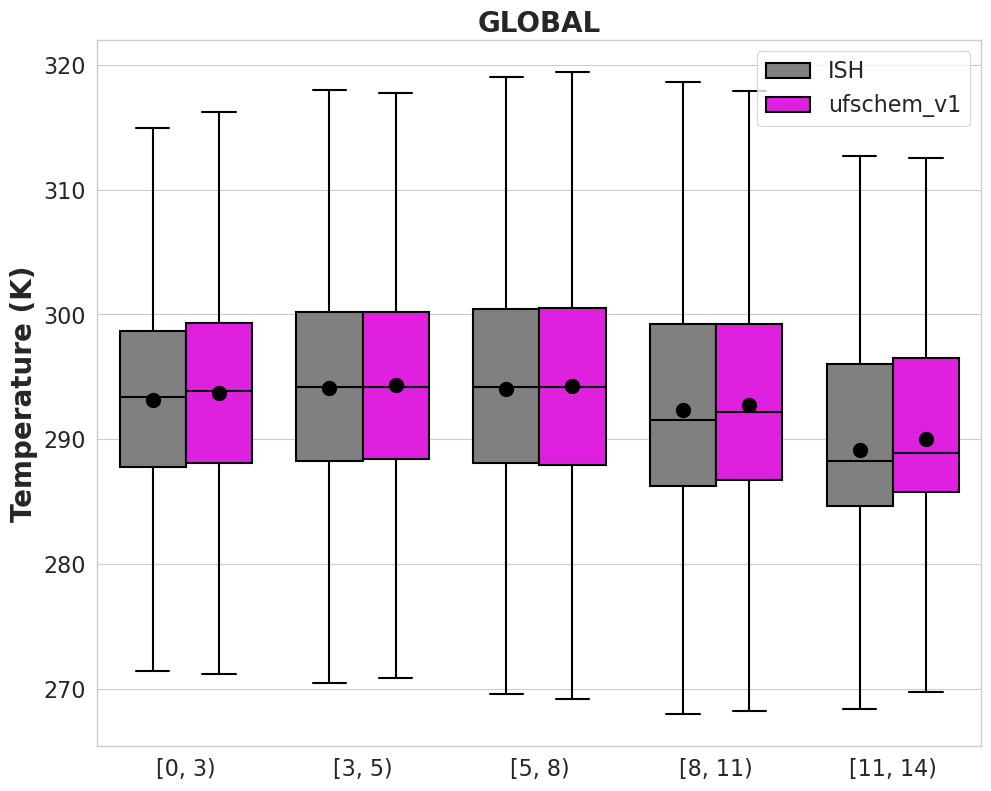

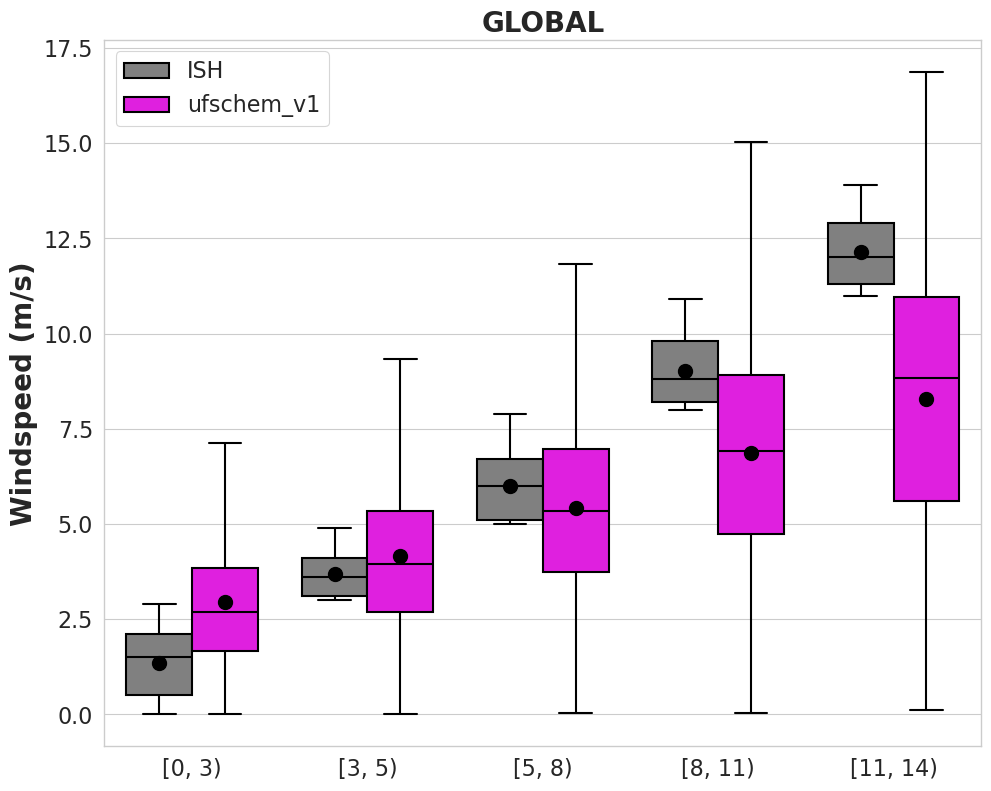

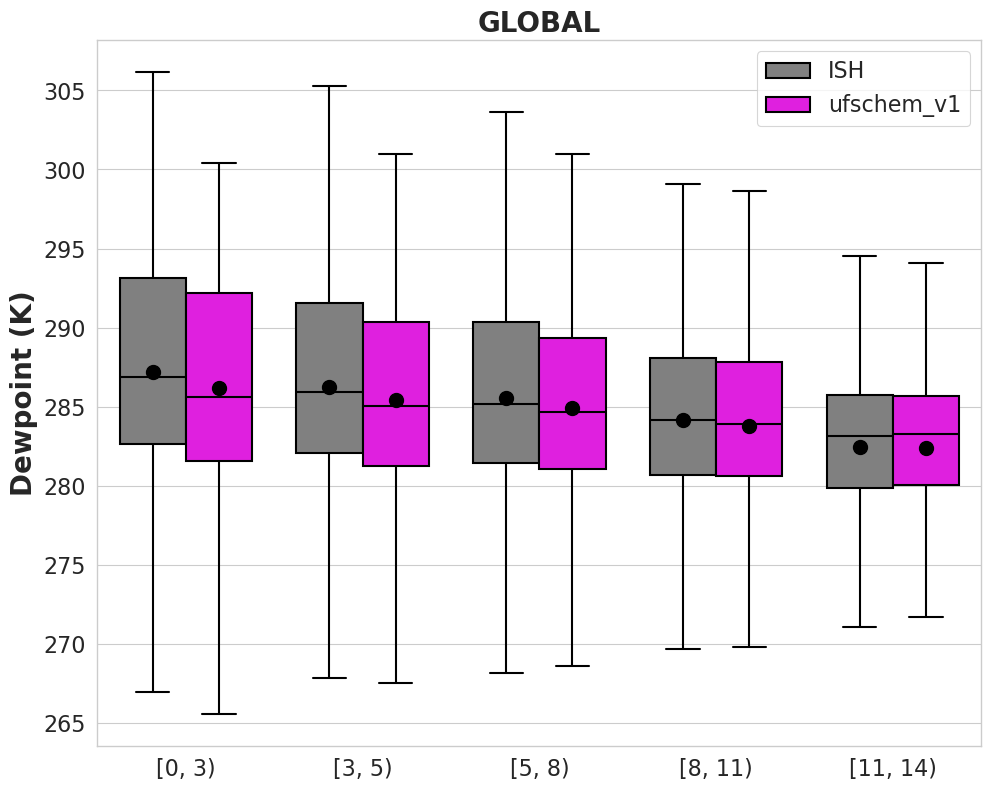

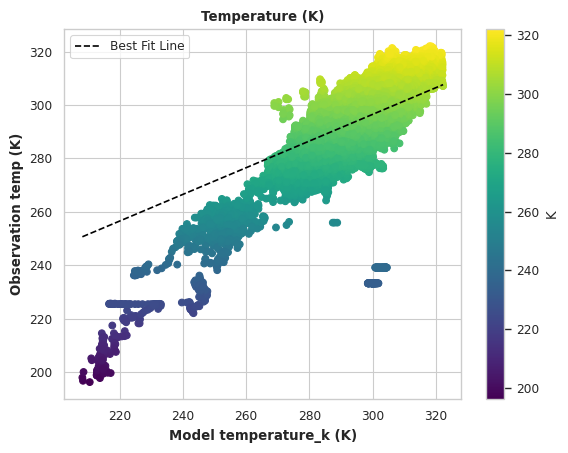

Value of fill after reading from scatter_density_config: False
Saving scatter density plot to ./output/ish_lite_ufschem/plot_grp6.scatter_density.ws.2017-07-01_00.2017-07-03_00.all.New York City_ish_lite_vs_ufschem_v1.png...
Processing scatter density plot for model 'ufschem_v1' and observation 'ish_lite'...
Generating scatter plot...
Saving scatter density plot to ./output/ish_lite_ufschem/plot_grp6.scatter_density.ws.2017-07-01_00.2017-07-03_00.all.New York City_ish_lite_vs_ufschem_v1.png...


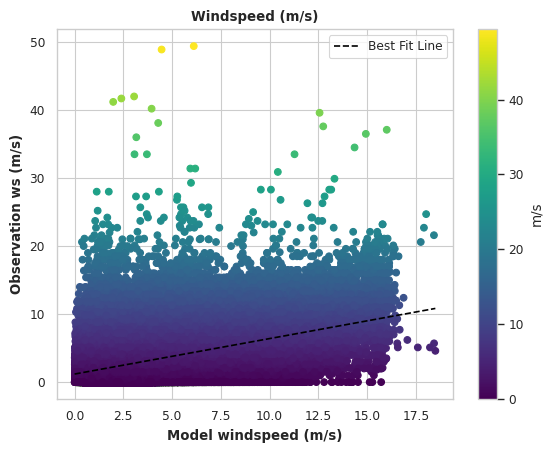

Value of fill after reading from scatter_density_config: False
Saving scatter density plot to ./output/ish_lite_ufschem/plot_grp6.scatter_density.dew_pt_temp.2017-07-01_00.2017-07-03_00.all.New York City_ish_lite_vs_ufschem_v1.png...
Processing scatter density plot for model 'ufschem_v1' and observation 'ish_lite'...
Generating scatter plot...
Saving scatter density plot to ./output/ish_lite_ufschem/plot_grp6.scatter_density.dew_pt_temp.2017-07-01_00.2017-07-03_00.all.New York City_ish_lite_vs_ufschem_v1.png...


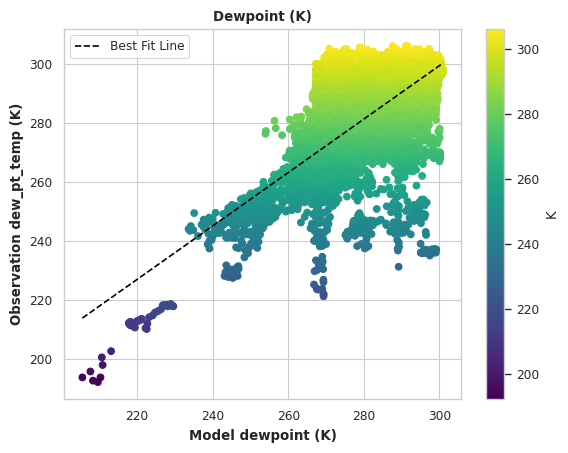

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.temp.2017-07-01_00.2017-07-03_00.all.GLOBAL...


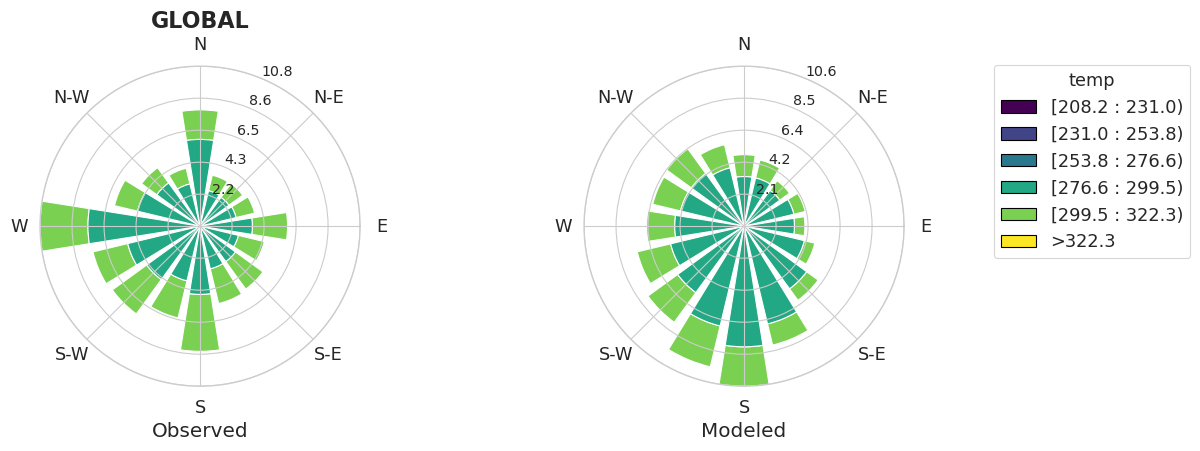

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.temp.2017-07-01_00.2017-07-03_00.all.CONUS...


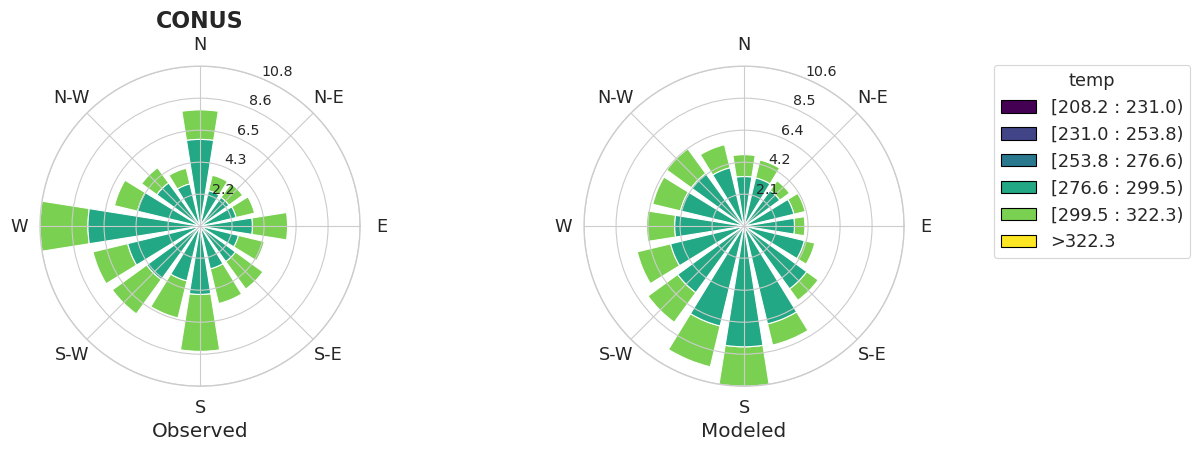

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.temp.2017-07-01_00.2017-07-03_00.state.CA...


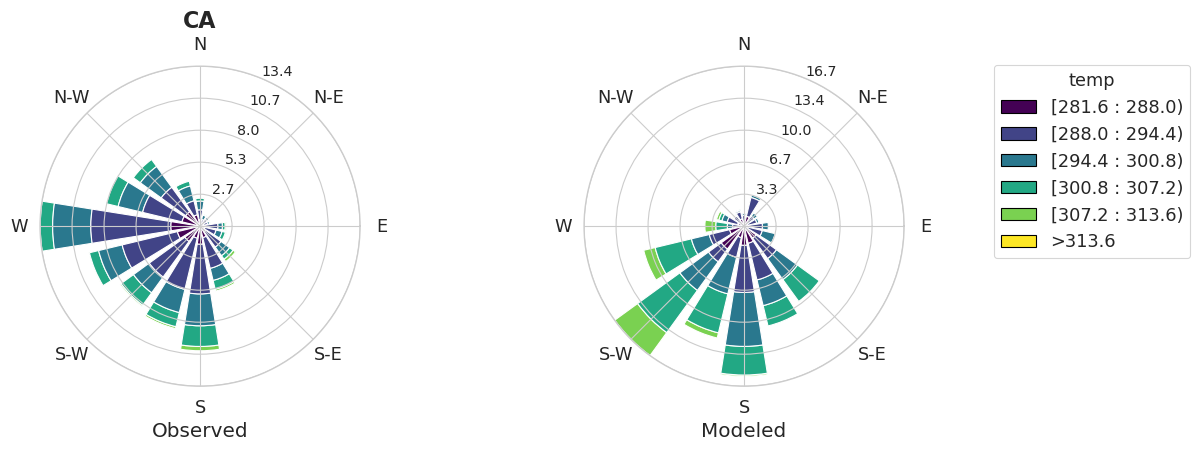

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.ws.2017-07-01_00.2017-07-03_00.all.GLOBAL...


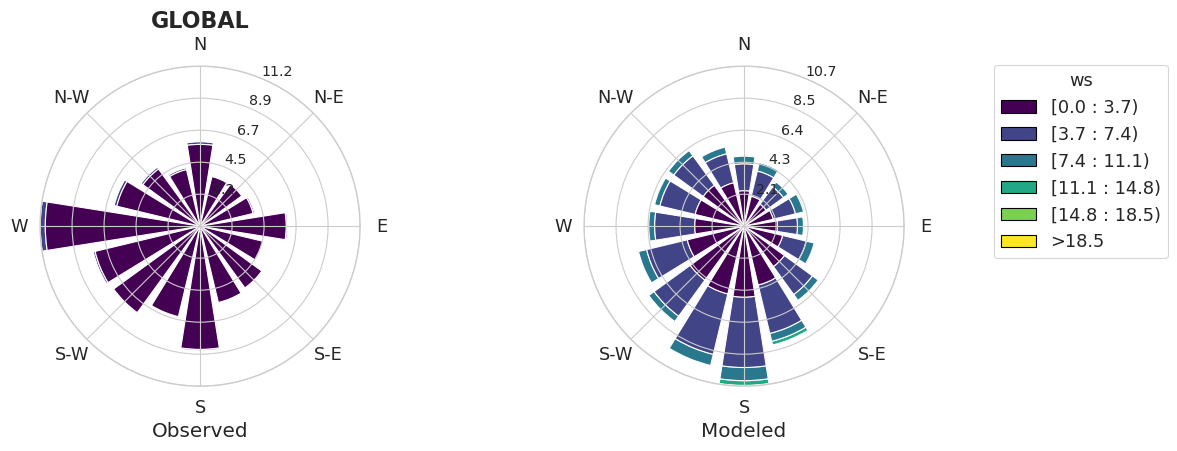

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.ws.2017-07-01_00.2017-07-03_00.all.CONUS...


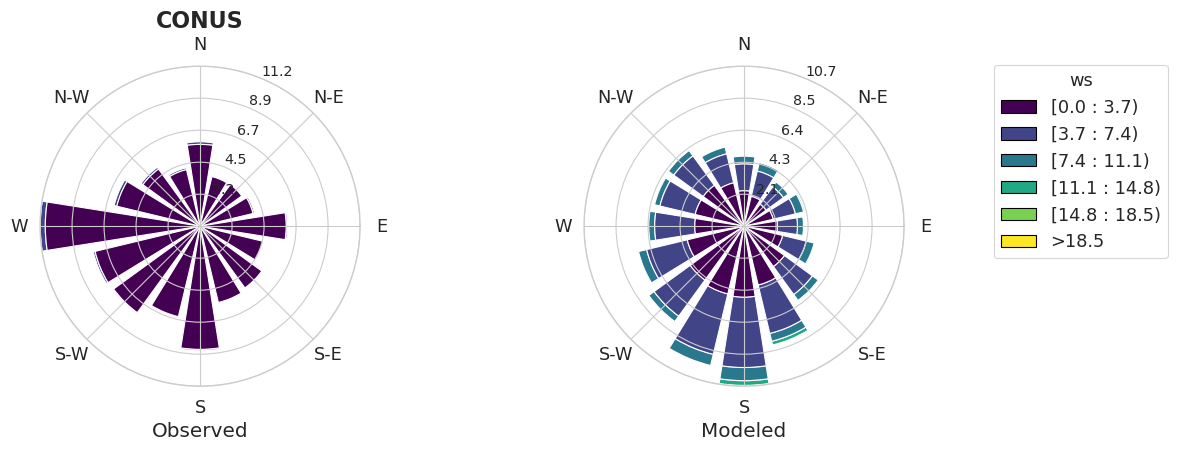

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.ws.2017-07-01_00.2017-07-03_00.state.CA...


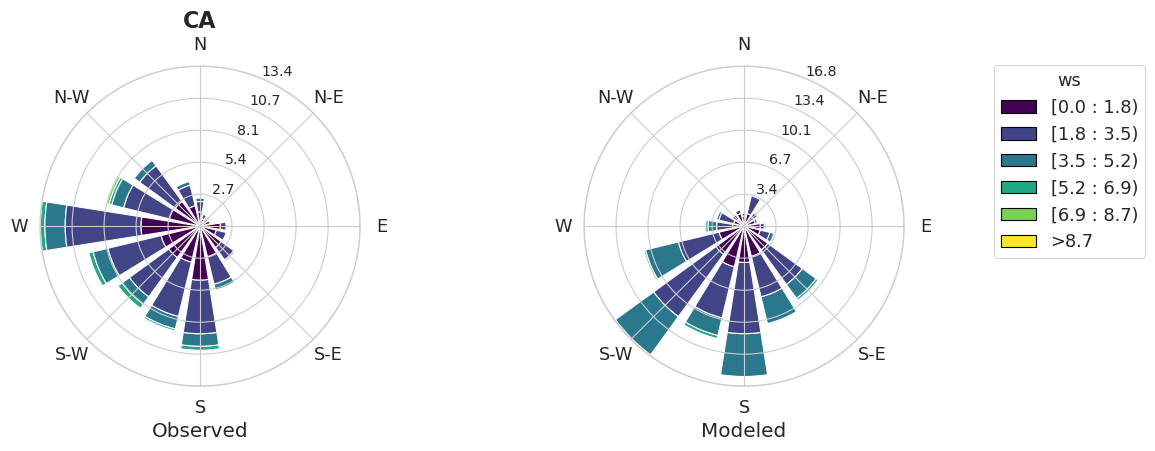

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.dew_pt_temp.2017-07-01_00.2017-07-03_00.all.GLOBAL...


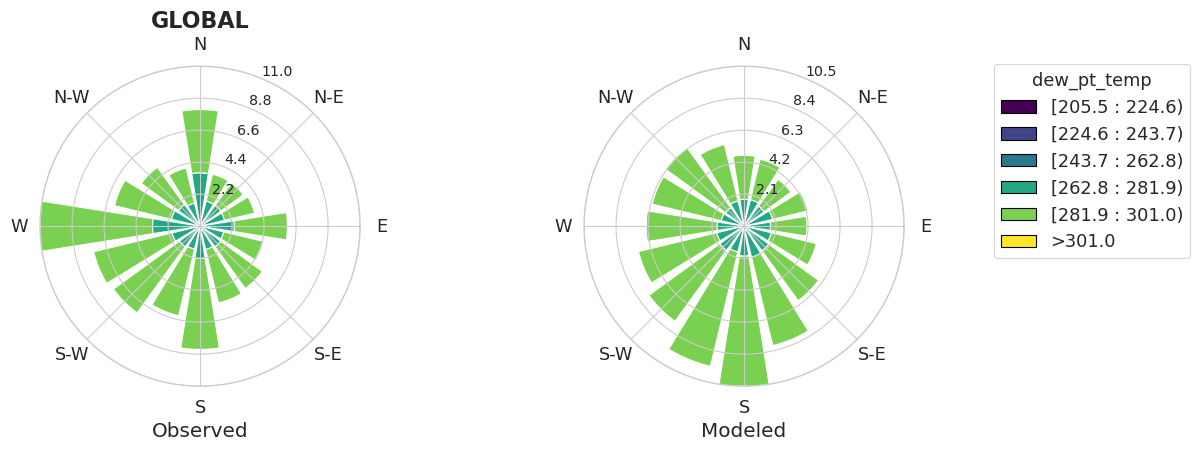

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.dew_pt_temp.2017-07-01_00.2017-07-03_00.all.CONUS...


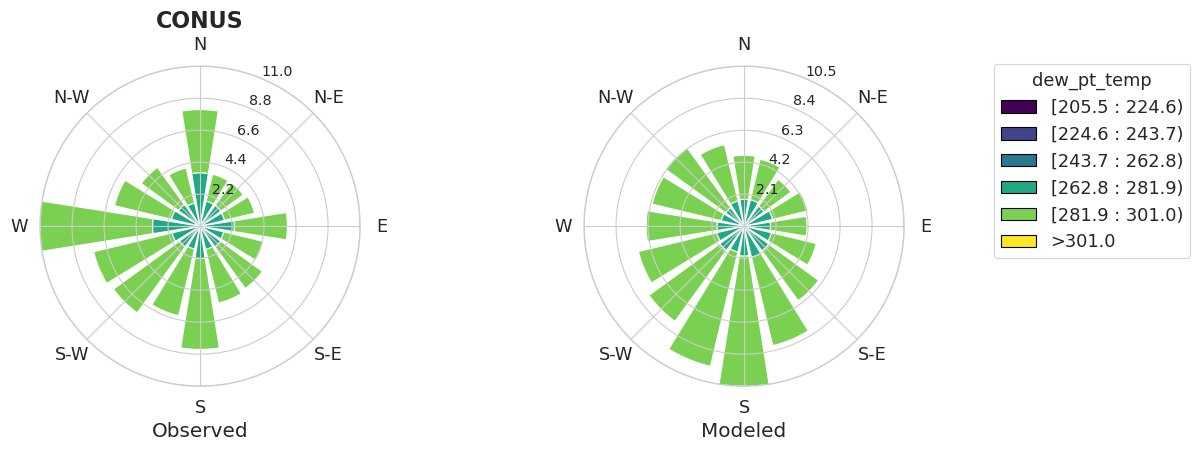

Saving rose plot to ./output/ish_lite_ufschem/plot_grp7.rose_plot.dew_pt_temp.2017-07-01_00.2017-07-03_00.state.CA...


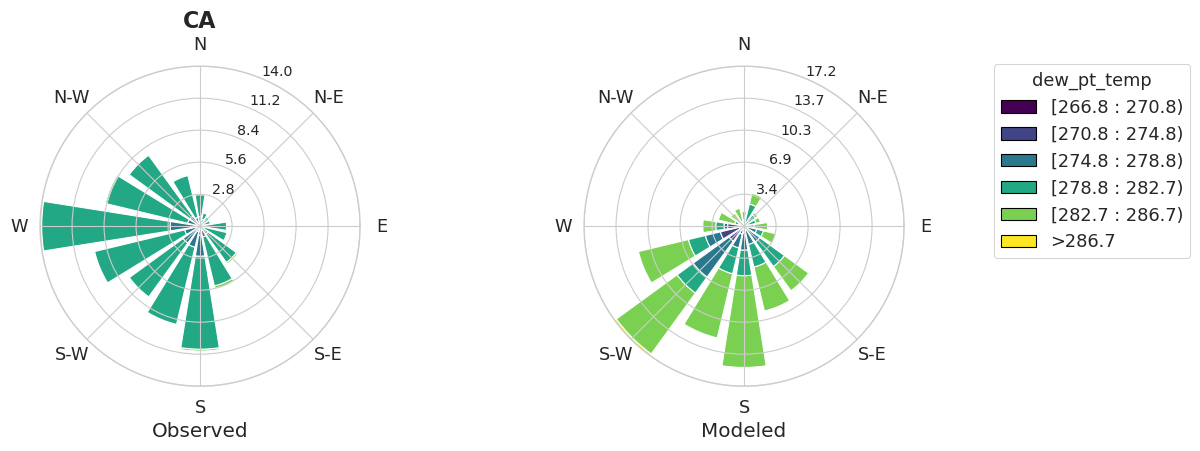

CPU times: user 3min 8s, sys: 10.7 s, total: 3min 18s
Wall time: 3min 13s


In [15]:
%%time

an.plotting()

CPU times: user 5.85 s, sys: 471 ms, total: 6.32 s
Wall time: 6.36 s


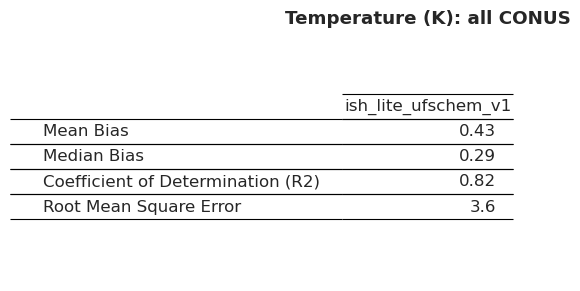

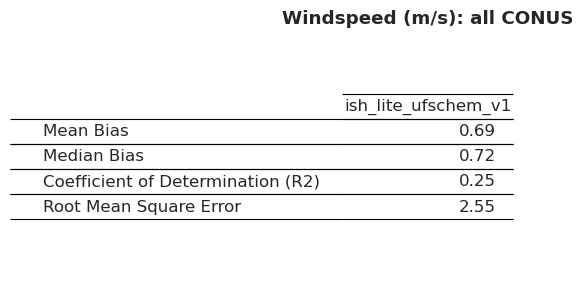

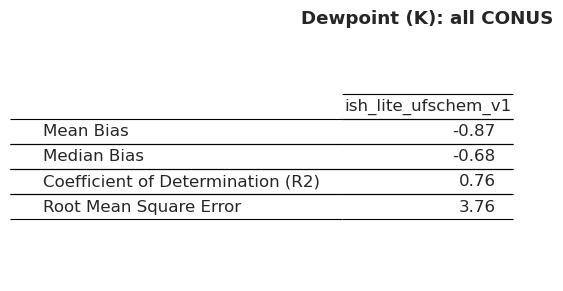

In [16]:
%%time

an.stats()

The stats routine has produced two files (one for each data variable).
This is one of them:
```{literalinclude} output/airnow_wrfchem/stats.OZONE.all.CONUS.2019-09-05_06.2019-09-06_06.csv
:caption:
```